In [1]:
import os
from pathlib import Path
import pandas as pd
from typing import Tuple
import joblib
from sklearn.preprocessing import StandardScaler

In [2]:
def extract_time_features(
    df: pd.DataFrame, datetime_col: str
) -> pd.DataFrame:
    """Extracts time-related features from a datetime column."""
    if datetime_col not in df.columns:
        raise ValueError(f"Column '{datetime_col}' not found.")

    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df['year'] = df[datetime_col].dt.year
    df['month'] = df[datetime_col].dt.month
    df['day'] = df[datetime_col].dt.day
    df['hour'] = df[datetime_col].dt.hour
    df['minute'] = df[datetime_col].dt.minute
    return df

In [3]:
DATA_DIR = Path('../../datasets/module_3/')
df = pd.read_csv(Path(DATA_DIR, 'feature_frame_filtered.csv'))

In [4]:
df["count_babies"].value_counts()

count_babies
0.0    2870356
1.0      10193
Name: count, dtype: int64

In [25]:
def split_dataframe_by_date(
    df: pd.DataFrame,
    train_ratio: float = 0.7, 
    val_ratio: float = 0.2, 
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Splits a dataframe into train (70%), validation (20%), and test (10%)
    based on the order_date column.
    
    Args:
        df (pd.DataFrame): Dataframe with 'order_id' and 'order_date' columns.
    
    Returns:
        tuple: (train_df, val_df, test_df)
    """
    # Ensure order_date is in datetime format
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'])
    
    # Sort by order_date
    df = df.sort_values(by='created_at')
    
    # Compute split indices
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * train_ratio) + int(n * val_ratio)
    
    # Split the dataframe
    train_df = df.iloc[:train_end]
    val_df = df.iloc[train_end:val_end]
    test_df = df.iloc[val_end:]
    
    return train_df, val_df, test_df

In [26]:
# For each user, it'd be interesting to define a split based on the user_order_sequence. This will avoid data leakage for the model in production.
def chronological_user_split(
    df: pd.DataFrame, 
    user_col: str, 
    order_col: str, 
    train_ratio: float = 0.5, 
    val_ratio: float = 0.3, 
    test_ratio: float = 0.2,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Splits a DataFrame into train, validation, and test sets chronologically per user.

    Parameters:
    - df: The input DataFrame.
    - user_col: The name of the column representing the user ID.
    - order_col: The name of the column representing the chronological sequence (e.g., user_order_seq).
    - train_ratio: Proportion of data to use for training (default: 0.7).
    - val_ratio: Proportion of data to use for validation (default: 0.15).
    - test_ratio: Proportion of data to use for testing (default: 0.15).

    Returns:
    - train_df: Training set
    - val_df: Validation set
    - test_df: Test set
    """
    assert train_ratio + val_ratio + test_ratio - 1.0 <= 0.001, "Ratios must sum to 1."

    train_list, val_list, test_list = [], [], []

    # Process each user separately
    for _, user_data in df.groupby(user_col):
        user_data = user_data.sort_values(by=order_col)

        n = len(user_data)
        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        train_list.append(user_data.iloc[:train_end])
        val_list.append(user_data.iloc[train_end:val_end])
        test_list.append(user_data.iloc[val_end:])

    # Combine all users' splits
    train_df = pd.concat(train_list)
    val_df = pd.concat(val_list)
    test_df = pd.concat(test_list)

    return train_df, val_df, test_df

In [27]:
#df = extract_time_features(df, datetime_col="created_at")

In [28]:
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [29]:
df = pd.get_dummies(df, columns=["product_type"], prefix="product")

In [30]:
df.head()

,variant_id,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,...,product_softdrinksmixers,product_superfoodssupplements,product_tea,product_tinspackagedfoods,product_toiletroll,product_washingcapsules,product_washingliquidgel,product_washingpowder,product_windowglasscleaner,product_wipescottonwool
0,33826472919172,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,33826472919172,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,33826472919172,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,33826472919172,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,33826472919172,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [31]:
train_df, val_df, test_df = split_dataframe_by_date(df)

In [32]:
train_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)
val_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)
test_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)

In [33]:
target_col = "outcome"
X_train, y_train = train_df.drop(columns=[target_col]), train_df[target_col].values
X_val, y_val = val_df.drop(columns=[target_col]), val_df[target_col].values
X_test, y_test = test_df.drop(columns=[target_col]), test_df[target_col].values

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Define the path to save the scaler
scaler_dir = "models"  # Use 'artifacts' if needed
os.makedirs(scaler_dir, exist_ok=True)  # Create the folder if it doesn't exist
scaler_path = os.path.join(scaler_dir, "scaler.pkl")

# Save the scaler
joblib.dump(scaler, scaler_path)

['models/scaler.pkl']

### Model

In [57]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb

In [58]:
def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test):
    models = {
        #'Ridge': Ridge(),
        #'Lasso': Lasso(),
        #'ElasticNet': ElasticNet(),
        'LogisticRegression': LogisticRegression(max_iter=100),
        #'RidgeClassifier': RidgeClassifier(max_iter=100),
        #'SGDClassifier': SGDClassifier(max_iter=10)
        #'XGBClassifier': xgb.XGBClassifier(eval_metric='mlogloss')
    }
    
    param_grid = {
        #'Ridge': {'model__alpha': [0.01, 0.1, 1, 10, 100]},
        #'Lasso': {'model__alpha': [0.01, 0.1, 1, 10, 100]},
        #'ElasticNet': {'model__alpha': [0.01, 0.1, 1, 10, 100], 'model__l1_ratio': [0.2, 0.5, 0.8]},
        'LogisticRegression': {'model__C': [1e-8, 1e-6, 1e-4, 1e-2, 1]},
        #'RidgeClassifier': {'model__alpha': [0.01, 1]},
        #'XGBClassifier': {'model__learning_rate': [0.01, 0.1]}
        #'SGDClassifier': {'model__alpha': [0.0001,  0.01]}
    }
    
    best_model = None
    best_score = float('inf')
    
    for name, model in models.items():
        pipeline = Pipeline([
            ('model', model)
        ])
        
        search = GridSearchCV(pipeline, param_grid[name], scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
        search.fit(X_train, y_train)
        
        val_predictions = search.best_estimator_.predict(X_val)
        val_score = mean_squared_error(y_val, val_predictions)
        
        print(f"{name}: Best Params: {search.best_params_}, Validation MSE: {val_score}")
        
        if val_score < best_score:
            best_score = val_score
            best_model = search.best_estimator_
    
    print("\nBest Model Selected:", best_model)
    
    test_predictions = best_model.predict_proba(X_test)
    test_score = mean_squared_error(y_test, test_predictions)
    print(f"Test MSE: {test_score}")
    
    return best_model

In [53]:
best_model = train_and_evaluate(X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)

LogisticRegression: Best Params: {'model__C': 0.0001}, Validation MSE: 0.010027616301776227

Best Model Selected: Pipeline(steps=[('model', LogisticRegression(C=0.0001))])
Test MSE: 0.009505096231288361


In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict the outcomes for the test set
y_test_pred = best_model.predict_proba(X_test_scaled)

A model that always predict no will be similar... The confussion matrix seems worrying to me :(
It's true that when it predicts true, it does quite well (~90%)... However, the models is missing a lot of potential candidates to buy!

In [62]:
y_test_pred

array([[9.99388458e-01, 6.11541606e-04],
       [9.99588447e-01, 4.11553260e-04],
       [9.99307926e-01, 6.92074039e-04],
       ...,
       [9.99599713e-01, 4.00287164e-04],
       [9.99486727e-01, 5.13272751e-04],
       [9.99781275e-01, 2.18725133e-04]], shape=(288056, 2))

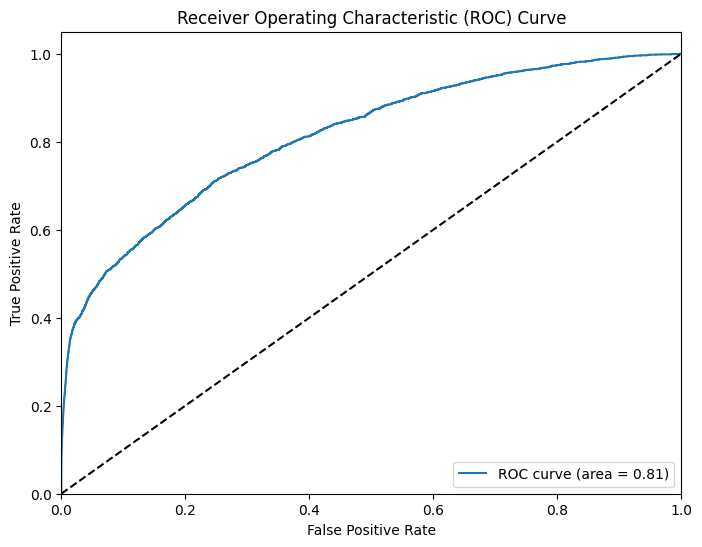

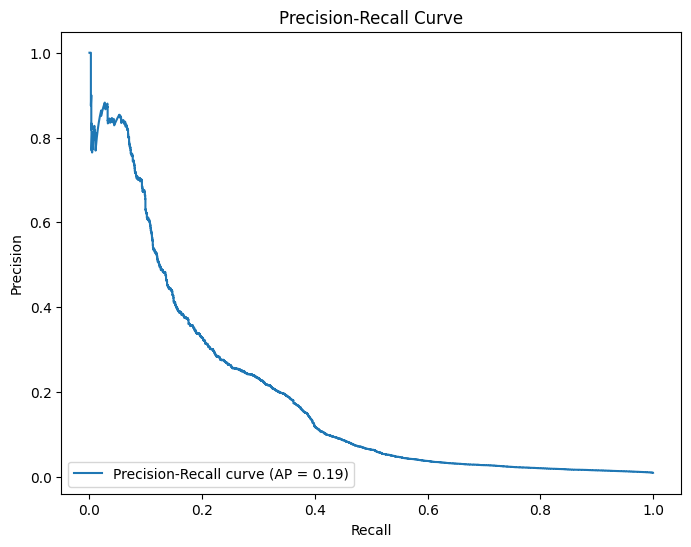

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

import matplotlib.pyplot as plt

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred[:, 1])

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_test_pred[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
# Calculate the precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_pred[:, 1])

# Calculate the average precision score
avg_precision = average_precision_score(y_test, y_test_pred[:, 1])

# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()